# Bellman-Ford Algorithm — Shortest Path with Negative Weights

Finds shortest paths from a source to all other nodes, and — unlike
Dijkstra's — correctly handles **negative edge weights** (e.g. representing
a toll rebate, a discount route, or a cost credit). It can also **detect
negative-weight cycles**, which would otherwise make "shortest path"
undefined (you could loop the cycle forever, decreasing distance infinitely).

Works by relaxing every edge, repeated (V - 1) times — this guarantees
finding shortest paths in a graph with no negative cycles, since the
longest possible shortest path uses at most V - 1 edges. One extra pass
is used afterward purely to detect negative cycles: if any edge can still
be relaxed after V - 1 passes, a negative cycle must exist.

- Time complexity: O(V × E) — significantly slower than Dijkstra's O((V+E) log V)
- Space complexity: O(V + E)

In [1]:
class Graph:
    def __init__(self):
        self.adj = {}

    def add_node(self, node):
        if node not in self.adj:
            self.adj[node] = []

    def add_edge(self, u, v, weight):
        self.add_node(u)
        self.add_node(v)
        self.adj[u].append((v, weight))

    def nodes(self):
        return list(self.adj.keys())

    def edges(self):
        result = []
        for u in self.adj:
            for v, w in self.adj[u]:
                result.append((u, v, w))
        return result

    def neighbors(self, u):
        return self.adj.get(u, [])

    def num_nodes(self):
        return len(self.adj)

    def num_edges(self):
        return sum(len(v) for v in self.adj.values())

    def __repr__(self):
        lines = []
        for u in self.adj:
            for v, w in self.adj[u]:
                lines.append(f"  {u} -> {v}  (weight={w})")
        return f"Graph({self.num_nodes()} nodes, {self.num_edges()} edges)\n" + "\n".join(lines)

In [2]:
def bellman_ford(graph: Graph, source, track_steps=False):
    """
    Returns (distances, predecessors, has_negative_cycle).
    If has_negative_cycle is True, distances/predecessors may not be meaningful
    for nodes reachable from the cycle.

    If track_steps=True, also returns a list of per-pass snapshots.
    """
    distances = {node: float('inf') for node in graph.nodes()}
    predecessors = {node: None for node in graph.nodes()}
    distances[source] = 0

    all_edges = graph.edges()
    n = graph.num_nodes()
    steps = []

    # Relax all edges (V - 1) times
    for i in range(n - 1):
        updated = False
        for u, v, w in all_edges:
            if distances[u] != float('inf') and distances[u] + w < distances[v]:
                distances[v] = distances[u] + w
                predecessors[v] = u
                updated = True

        if track_steps:
            steps.append({"pass": i + 1, "distances": distances.copy()})

        if not updated:
            break  # early exit — no more improvements possible

    # One more pass to detect negative cycles
    has_negative_cycle = False
    for u, v, w in all_edges:
        if distances[u] != float('inf') and distances[u] + w < distances[v]:
            has_negative_cycle = True
            break

    if track_steps:
        return distances, predecessors, has_negative_cycle, steps
    return distances, predecessors, has_negative_cycle

## Sanity Test 1 — Same network as Dijkstra's (no negative weights, results should match)

In [3]:
g = Graph()
edges = [
    ("Kathmandu", "Bhaktapur", 25),
    ("Kathmandu", "Lalitpur", 15),
    ("Lalitpur", "Bhaktapur", 20),
    ("Bhaktapur", "Dhulikhel", 30),
    ("Lalitpur", "Dhulikhel", 45),
    ("Dhulikhel", "Nagarkot", 35),
    ("Kathmandu", "Nagarkot", 60),
    ("Nagarkot", "Bhaktapur", 28),
]
for u, v, w in edges:
    g.add_edge(u, v, w)

distances, predecessors, has_neg_cycle = bellman_ford(g, "Kathmandu")

print("Shortest distances from Kathmandu (Bellman-Ford):")
for node, dist in distances.items():
    print(f"  {node}: {dist}")
print("\nHas negative cycle:", has_neg_cycle)
print("(Should match Dijkstra's earlier result exactly: Kathmandu=0, Lalitpur=15, Bhaktapur=25, Dhulikhel=55, Nagarkot=60)")

Shortest distances from Kathmandu (Bellman-Ford):
  Kathmandu: 0
  Bhaktapur: 25
  Lalitpur: 15
  Dhulikhel: 55
  Nagarkot: 60

Has negative cycle: False
(Should match Dijkstra's earlier result exactly: Kathmandu=0, Lalitpur=15, Bhaktapur=25, Dhulikhel=55, Nagarkot=60)


## Sanity Test 2 — Negative Edge Weight (No Cycle)

Demonstrates Bellman-Ford correctly handling a negative edge, which
Dijkstra's algorithm cannot do (it would produce a wrong/incomplete answer,
or we'd need to explicitly block it — see our `dijkstra()` implementation,
which raises an error rather than silently giving a wrong result).

In [4]:
g2 = Graph()
edges2 = [
    ("A", "B", 10),
    ("A", "C", 5),
    ("C", "B", -8),   # negative edge: a shortcut discount from C to B
    ("B", "D", 2),
    ("C", "D", 12),
]
for u, v, w in edges2:
    g2.add_edge(u, v, w)

distances2, predecessors2, has_neg_cycle2 = bellman_ford(g2, "A")

print("Shortest distances from A:")
for node, dist in distances2.items():
    print(f"  {node}: {dist}")
print("\nHas negative cycle:", has_neg_cycle2)

# Expected: A->C->B is 5 + (-8) = -3, which beats A->B direct (10)
# So shortest to B should be -3, and shortest to D should be -3 + 2 = -1
print("\nExpected: B = -3 (via A->C->B, beating direct A->B=10), D = -1 (via A->C->B->D)")

# Demonstrate that Dijkstra's would break here:
def dijkstra(graph, source):
    import heapq
    distances = {node: float('inf') for node in graph.nodes()}
    distances[source] = 0
    visited = set()
    pq = [(0, source)]
    while pq:
        dist_u, u = heapq.heappop(pq)
        if u in visited:
            continue
        visited.add(u)
        for v, weight in graph.neighbors(u):
            if weight < 0:
                raise ValueError(f"Dijkstra's algorithm cannot handle negative edge weight: {u}->{v} = {weight}")
            new_dist = dist_u + weight
            if new_dist < distances[v]:
                distances[v] = new_dist
                heapq.heappush(pq, (new_dist, v))
    return distances

try:
    dijkstra(g2, "A")
except ValueError as e:
    print(f"\nDijkstra's on the same graph raises: {e}")

Shortest distances from A:
  A: 0
  B: -3
  C: 5
  D: -1

Has negative cycle: False

Expected: B = -3 (via A->C->B, beating direct A->B=10), D = -1 (via A->C->B->D)

Dijkstra's on the same graph raises: Dijkstra's algorithm cannot handle negative edge weight: C->B = -8


## Sanity Test 3 — Negative Cycle Detection

A negative cycle makes "shortest path" undefined — you could loop the cycle
forever, decreasing total distance without bound. Bellman-Ford must detect
and report this rather than returning a misleading finite answer.

In [5]:
g3 = Graph()
edges3 = [
    ("A", "B", 4),
    ("B", "C", -6),
    ("C", "D", 2),
    ("D", "B", 1),   # B -> C -> D -> B = -6 + 2 + 1 = -3 (negative cycle!)
]
for u, v, w in edges3:
    g3.add_edge(u, v, w)

distances3, predecessors3, has_neg_cycle3 = bellman_ford(g3, "A")

print("Has negative cycle:", has_neg_cycle3)
print("(Expected: True — the cycle B->C->D->B sums to -6+2+1 = -3, a negative cycle)")
print("\nDistances (may be unreliable due to the negative cycle):")
for node, dist in distances3.items():
    print(f"  {node}: {dist}")

Has negative cycle: True
(Expected: True — the cycle B->C->D->B sums to -6+2+1 = -3, a negative cycle)

Distances (may be unreliable due to the negative cycle):
  A: 0
  B: -5
  C: -8
  D: -6


## Visualizing Distance Convergence Across Passes

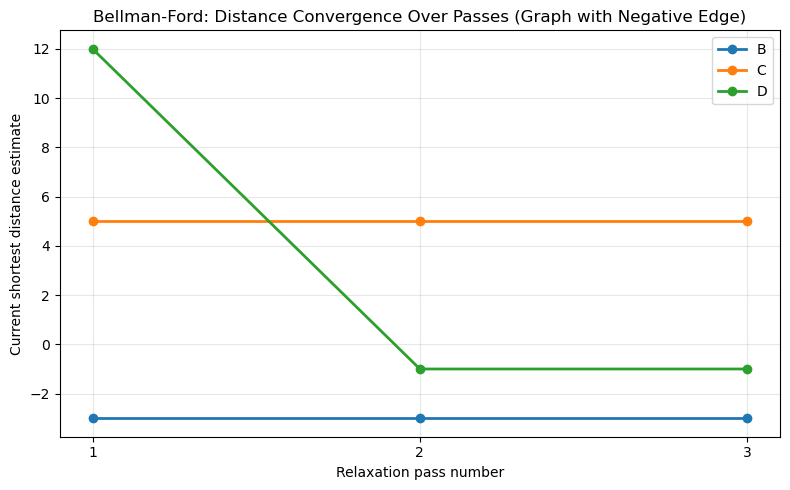

Number of passes until convergence: 3 (max possible: 3)


In [6]:
import matplotlib.pyplot as plt

# Re-run on the negative-weight (non-cycle) graph with step tracking
distances2, predecessors2, has_neg_cycle2, steps2 = bellman_ford(g2, "A", track_steps=True)

nodes_to_plot = [n for n in g2.nodes() if n != "A"]  # skip source, it's always 0
fig, ax = plt.subplots(figsize=(8, 5))

for node in nodes_to_plot:
    values = [step["distances"][node] for step in steps2]
    passes = [step["pass"] for step in steps2]
    ax.plot(passes, values, marker='o', label=node, linewidth=2)

ax.set_xlabel("Relaxation pass number")
ax.set_ylabel("Current shortest distance estimate")
ax.set_title("Bellman-Ford: Distance Convergence Over Passes (Graph with Negative Edge)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(passes)
plt.tight_layout()
plt.show()

print("Number of passes until convergence:", len(steps2), f"(max possible: {g2.num_nodes() - 1})")

## Visualizing a Negative Cycle — Distances Never Converge

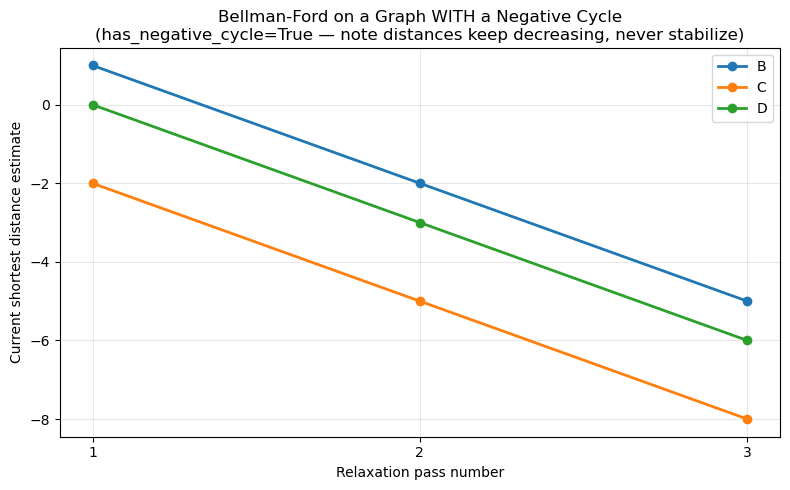

Ran all 3 passes (= V-1 = 3) without early exit — distances were still changing on the final pass, confirming the negative cycle.


In [7]:
distances3, predecessors3, has_neg_cycle3, steps3 = bellman_ford(g3, "A", track_steps=True)

nodes_to_plot3 = [n for n in g3.nodes() if n != "A"]
fig, ax = plt.subplots(figsize=(8, 5))

for node in nodes_to_plot3:
    values = [step["distances"][node] for step in steps3]
    passes = [step["pass"] for step in steps3]
    ax.plot(passes, values, marker='o', label=node, linewidth=2)

ax.set_xlabel("Relaxation pass number")
ax.set_ylabel("Current shortest distance estimate")
ax.set_title(f"Bellman-Ford on a Graph WITH a Negative Cycle\n(has_negative_cycle={has_neg_cycle3} — note distances keep decreasing, never stabilize)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(passes)
plt.tight_layout()
plt.show()

print(f"Ran all {len(steps3)} passes (= V-1 = {g3.num_nodes()-1}) without early exit — distances were still changing on the final pass, confirming the negative cycle.")